In [37]:
# === Global figure style: pure black axes / labels / legend ===
import matplotlib.pyplot as plt

plt.rcParams.update({
    # Axes
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',

    # Ticks
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,

    # Text
    'text.color': 'black',

    # Legend
    'legend.edgecolor': 'black',
    'legend.labelcolor': 'black',
    'legend.frameon': False,

    # Publication-friendly font sizing
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})


# proxy_energy_correlation

This notebook:
- loads `proxy_energy_correlation.csv`
- computes **Pearson correlation** (r) and **p-value** between **FGW score** and **relaxed energy**
- plots a journal-style **scatter + linear fit + 95% confidence band**, annotated with r and p

**Input file**: `proxy_energy_correlation.csv`  
**Required columns**: `fgw_score`, `relaxed_energy_eV`

### Styling
- No plot title (to match journal figure panels).
- Uses a deterministic **3-style color cycle** (blue / orange / green) based on the CSV path,
  so different CSV inputs tend to get different colors.
- Gray band is the **95% CI for the fitted regression line (mean prediction)**.


In [38]:
import pandas as pd
from pathlib import Path

csv_path = Path("proxy_energy_correlation.csv")
df = pd.read_csv(csv_path)

print("shape:", df.shape)
display(df.head())
print("columns:", list(df.columns))


shape: (24, 7)


,group,grid_idx,shift_a,shift_b,shift_c,fgw_score,relaxed_energy_eV
0,fgw_lowest_top8,50,0.750,0.25,-2.4,0.180234,-978.125854
1,fgw_lowest_top8,22,0.250,0.75,-2.4,0.180234,-978.124084
2,fgw_lowest_top8,44,0.625,0.50,-2.4,0.180595,-978.557922
3,fgw_lowest_top8,8,0.125,0.00,-2.4,0.180595,-978.557556
4,fgw_lowest_top8,28,0.375,0.50,-2.4,0.180595,-978.583984


columns: ['group', 'grid_idx', 'shift_a', 'shift_b', 'shift_c', 'fgw_score', 'relaxed_energy_eV']


In [39]:
import matplotlib as mpl

# --- Global journal styling ---
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 9
mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["axes.titlesize"] = 9
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["axes.linewidth"] = 0.8

mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from matplotlib import colors

def _format_p(p: float) -> str:
    if p < 1e-4:
        return f"{p:.1e}"
    return f"{p:.4f}"

def _single_hue_cmap(base_color="#1f4e79", n=256, dark_mix=0.45, light_mix=0.82):
    """Create a stronger single-hue scientific gradient.
    The dark end is pushed closer to black, and the light end closer to white.
    """
    base = np.array(colors.to_rgb(base_color))
    dark = tuple((1 - dark_mix) * base)
    light = tuple(base + light_mix * (1 - base))
    return colors.LinearSegmentedColormap.from_list("single_hue_strong", [dark, tuple(light)], N=n)

def plot_corr(ax, data, xcol, ycol):
    d = data[[xcol, ycol]].dropna()
    x = d[xcol].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)

    # Diagonal gradient scalar
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    c = 0.5 * (x_norm + y_norm)

    norm = colors.PowerNorm(gamma=0.8, vmin=0.0, vmax=1.0)
    cmap = _single_hue_cmap("#1f4e79")  # stronger deep scientific blue

    # Stats
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    # Regression + 95% CI
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    xs = np.linspace(np.min(x), np.max(x), 200)
    Xs = sm.add_constant(xs)
    pred = model.get_prediction(Xs)
    mean = pred.predicted_mean
    ci_low, ci_high = pred.conf_int(alpha=0.05).T

    # CI band (gray) + regression line
    ax.fill_between(xs, ci_low, ci_high, color="0.90", linewidth=0)
    ax.plot(xs, mean, linewidth=1.1, color="black")

    # Scatter
    ax.scatter(
        x, y,
        c=c,
        cmap=cmap,
        norm=norm,
        s=22,
        alpha=0.98,
        edgecolors="none"
    )

    # Bold axis labels
    ax.set_xlabel("FGW score", fontsize=12, fontweight="bold", color="black")
    ax.set_ylabel("Relaxed energy (eV)", fontsize=12, fontweight="bold", color="black")

    # Pearson + Spearman (rank consistency is often more important for screening)
    ax.text(
        0.04, 0.96,
        "\n".join([
            f"r = {pearson_r:.4f}, ρ = {spearman_rho:.4f}",
        ]),
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

    # Full box spines
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(0.8)
        sp.set_color("black")

    # Make ticks point outward for a cleaner journal-style frame
    ax.tick_params(direction="out", length=3.6, width=0.8, colors="black")
    ax.grid(False)

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
    }


Saved: C:\Users\20655\PycharmProjects\RegFGW\examples\proxy_energy_correlation\proxy_energy_correlation.png
Saved: C:\Users\20655\PycharmProjects\RegFGW\examples\proxy_energy_correlation\proxy_energy_correlation.pdf
Pearson r = 0.413857, Spearman rho = 0.483436


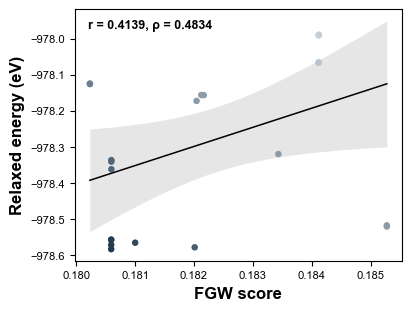

In [41]:
from pathlib import Path
import matplotlib.pyplot as plt

xcol = "fgw_score"
ycol = "relaxed_energy_eV"

missing = [c for c in (xcol, ycol) if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

# Conventional single-panel ratio (journal-friendly)
fig, ax = plt.subplots(1, 1, figsize=(4.0, 3.0), constrained_layout=True)

stats = plot_corr(ax, df, xcol=xcol, ycol=ycol)

out_png = Path("proxy_energy_correlation.png")
out_pdf = Path("proxy_energy_correlation.pdf")
fig.savefig(out_png, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

print("Saved:", out_png.resolve())
print("Saved:", out_pdf.resolve())
print(f"Pearson r = {stats['pearson_r']:.6f}, Spearman rho = {stats['spearman_rho']:.6f}")

plt.show()


In [42]:
# If you prefer publication-style axis names:
# - Rename x label to something like 'Proxy score (FGW)'
# - Rename y label to 'Relaxed energy (eV)'
# - Optionally invert y-axis if you want 'better' (lower energy) to go up

# Example tweak:
# for ax in plt.gcf().axes:
#     ax.set_xlabel("Proxy score (FGW)")
#     ax.set_ylabel("Relaxed energy (eV)")
#     ax.invert_yaxis()
